# Tutorial 8: Train NicheTrans on human lymph node data

In [32]:
import os, time, datetime, warnings

import torch
import torch.nn as nn
from torch.optim import lr_scheduler

from model.nicheTrans_img import *
from datasets.data_manager_human_lymph_node import Lymph_node

from utils.utils import *
from utils.utils_training_human_lymph_node import train, test
from utils.utils_dataloader import *

warnings.filterwarnings("ignore")

### Initialize the args and fix seeds

In [33]:
%run ./args/args_human_lymph_node.py
args = args

set_seed(args.seed)
os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu_devices

print("==========\nArgs:{}\n==========".format(args))

Args:Namespace(noise_rate=0.5, dropout_rate=0.1, use_moe_ffn=True, num_experts=2, moe_gate_hidden_dim=256, moe_gate_type='softmax', ffn_mult=2, n_source=3000, workers=4, adata_path='/mnt/datadisk0/Processed_DATA/2024_nm_human_lymph_nodes/', max_epoch=20, stepsize=10, train_batch=32, test_batch=32, optimizer='adam', lr=0.0003, gamma=0.1, weight_decay=0.0005, seed=1, save_dir='./log', eval_step=1, gpu_devices='0')


### Initialize dataloaders and NicheTrans

In [34]:
# create the dataloaders
dataset = Lymph_node(adata_path=args.adata_path, n_top_genes=args.n_source)
trainloader, testloader = human_node_dataloader(args, dataset)

# create the model
source_dimension, target_dimension = dataset.rna_length, dataset.protein_length
model = NicheTrans(source_length=source_dimension, target_length=target_dimension, noise_rate=args.noise_rate, dropout_rate=args.dropout_rate,num_experts=args.num_experts,moe_gate_hidden_dim=args.moe_gate_hidden_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

------Calculating spatial graph...
The graph contains 13638 edges, 3484 cells.
3.9145 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 27174 edges, 3484 cells.
7.7997 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 13138 edges, 3359 cells.
3.9113 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 26192 edges, 3359 cells.
7.7976 neighbors per cell on average.
=> Human lymph node loaded
Dataset statistics:
  ------------------------------
  subset   | # num | 
  ------------------------------
  train    |  After filting  3484 spots
  test     |  After filting  3359 spots
  ------------------------------


### Initialize loss function (criterion) and optimizer

In [35]:
criterion = nn.MSELoss()

if args.optimizer == 'adam':
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
elif args.optimizer == 'SGD':
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr)
else:
    print('unexpected optimizer')

if args.stepsize > 0:
    scheduler = lr_scheduler.StepLR(optimizer, step_size=args.stepsize, gamma=args.gamma)

### Optional MoE Trajectory Tracking During Training

Enable the next cell if you want to monitor whether expert usage becomes more balanced or more specialized across epochs.


In [40]:
from utils.moe_analysis import analyze_moe_routing, summarize_epoch_trajectory

track_moe_during_training = True
moe_track_every = 1
moe_track_max_batches = None  # Set to a small integer for faster monitoring on large datasets.
moe_epoch_frames = {}
moe_epoch_overall = []



### Model training and testing

In [41]:
start_time = time.time()

if "track_moe_during_training" not in globals():
    track_moe_during_training = False
    moe_track_every = 1
    moe_track_max_batches = None
    moe_epoch_frames = {}
    moe_epoch_overall = []

for epoch in range(args.max_epoch):
    last_epoch = epoch + 1 == args.max_epoch

    print("==> Epoch {}/{}".format(epoch+1, args.max_epoch))
    
    ################
    train(model, criterion, optimizer, trainloader, device=device)
    if args.stepsize > 0: scheduler.step()

    if track_moe_during_training and ((epoch + 1) % moe_track_every == 0 or last_epoch):
        moe_epoch_result = analyze_moe_routing(
            model=model,
            dataloader=testloader,
            device=device,
            include_images=False,
            include_cell_information=False,
            include_predictions=False,
            include_targets=False,
            max_batches=moe_track_max_batches,
            add_spatial_regions=False,
        )
        moe_epoch_frames[epoch + 1] = moe_epoch_result["activation_frame"]
        moe_epoch_overall.append({"epoch": epoch + 1, **moe_epoch_result["overall"]})
        print("MoE tracking at epoch {}:".format(epoch + 1), moe_epoch_result["overall"])
    ################
    
pearson = test(model, testloader, device=device)
torch.save(model.state_dict(), 'NicheTrans_human_lymph_node_last.pth')

elapsed = round(time.time() - start_time)
elapsed = str(datetime.timedelta(seconds=elapsed))
print("Finished. Total elapsed time (h:m:s): {}".format(elapsed))


==> Epoch 1/20
Batch 108/108	 Loss 0.823398 (0.645878)
MoE tracking at epoch 1: {'num_center_spots': 3359, 'num_experts': 2, 'usage_entropy_normalised': 0.9998848482249216, 'top1_entropy_normalised': 0.6173508153930504, 'effective_expert_count': 1.9998403721141405, 'dominant_expert_fraction': 0.5063172344758277, 'mean_weight_l1_to_uniform': 0.012634468605632554, 'top1_l1_to_uniform': 0.6939565346829413, 'mean_spot_entropy': 0.6929978843468426, 'std_spot_entropy': 0.0001848072752975233}
==> Epoch 2/20
Batch 108/108	 Loss 0.851626 (0.651553)
MoE tracking at epoch 2: {'num_center_spots': 3359, 'num_experts': 2, 'usage_entropy_normalised': 0.9999240435157921, 'top1_entropy_normalised': 0.7256043451396228, 'effective_expert_count': 1.999894704726123, 'dominant_expert_fraction': 0.5051306876780626, 'mean_weight_l1_to_uniform': 0.010261374726186212, 'top1_l1_to_uniform': 0.5963084251265258, 'mean_spot_entropy': 0.6930296711335581, 'std_spot_entropy': 0.00015815739090278442}
==> Epoch 3/20
Bat

### Optional MoE Routing Analysis

Run the next cell after training if you want to inspect expert activation, load balance, and spatial specialization.


Overall MoE metrics:
{'num_center_spots': 3359, 'num_experts': 2, 'usage_entropy_normalised': 0.9999312110174281, 'top1_entropy_normalised': 0.8292784683705029, 'effective_expert_count': 1.9999046404947844, 'dominant_expert_fraction': 0.5048826403137331, 'mean_weight_l1_to_uniform': 0.009765281372746015, 'top1_l1_to_uniform': 0.47662994938969927, 'mean_spot_entropy': 0.6930105265111838, 'std_spot_entropy': 0.0001895221614678684}


,expert,average_activation_weight,top1_selection_frequency
0,0,0.504883,0.738315
1,1,0.495117,0.261685


,slice_id,expert_0_mean_weight,expert_1_mean_weight,expert_0_top1_frequency,expert_1_top1_frequency,num_center_spots,normalised_entropy,top1_normalised_entropy,effective_expert_count,dominant_expert_fraction,mean_weight_l1_to_uniform,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy
0,default,0.504883,0.495117,0.738315,0.261685,3359,0.999931,0.829278,1.999905,0.504883,0.009765,0.47663,0.693011,0.00019


,spatial_region,expert_0_mean_weight,expert_1_mean_weight,expert_0_top1_frequency,expert_1_top1_frequency,num_center_spots,normalised_entropy,top1_normalised_entropy,effective_expert_count,dominant_expert_fraction,mean_weight_l1_to_uniform,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy
0,default|x0_y0,0.501994,0.498006,0.582418,0.417582,910,0.999989,0.980311,1.999984,0.501994,0.003989,0.164835,0.693060,0.000149
1,default|x0_y1,0.502801,0.497199,0.625974,0.374026,770,0.999977,0.953713,1.999969,0.502801,0.005601,0.251948,0.693059,0.000141
2,default|x1_y0,0.506625,0.493375,0.831169,0.168831,770,0.999873,0.655024,1.999824,0.506625,0.013250,0.662338,0.692974,0.000220
3,default|x1_y1,0.508062,0.491938,0.910891,0.089109,909,0.999812,0.433488,1.999740,0.508062,0.016124,0.821782,0.692951,0.000208


,sample_id,slice_id,spot_id,x,y,batch_index,batch_spot_index,top1_expert,top1_weight,center_entropy,...,target_22,target_23,target_24,target_25,target_26,target_27,target_28,target_29,target_30,spatial_region
0,14_0,default,14_0,14.0,0.0,51,18,1,0.500297,0.693147,...,0.085699,0.184208,0.332505,1.297080,0.601530,1.003018,0.196651,0.449594,0.986500,default|x0_y0
1,16_0,default,16_0,16.0,0.0,54,13,1,0.503710,0.693120,...,0.112855,-2.057792,-1.299184,0.014043,-0.773163,-0.076710,-2.354436,-0.976474,-0.086805,default|x0_y0
2,18_0,default,18_0,18.0,0.0,10,14,1,0.507108,0.693046,...,0.759769,0.193185,0.750456,0.657912,0.422595,0.727902,-0.004481,0.175593,0.472729,default|x0_y0
3,20_0,default,20_0,20.0,0.0,2,15,1,0.507577,0.693032,...,0.572739,-0.263944,0.233377,0.120309,0.369121,-1.205086,0.073081,-0.042643,0.270023,default|x0_y0
4,22_0,default,22_0,22.0,0.0,95,7,1,0.506837,0.693054,...,0.400436,0.213515,0.246174,0.393011,0.127433,0.046691,0.188135,0.327717,0.254237,default|x0_y0


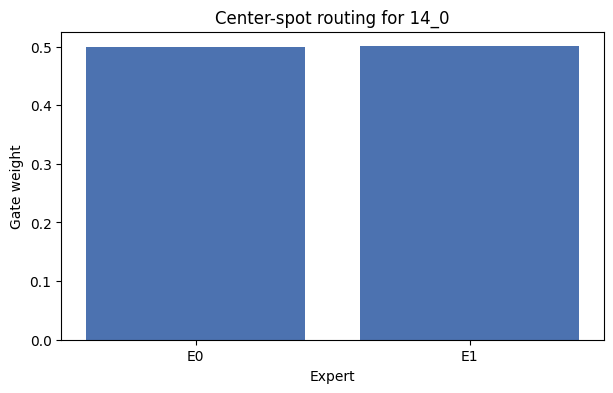

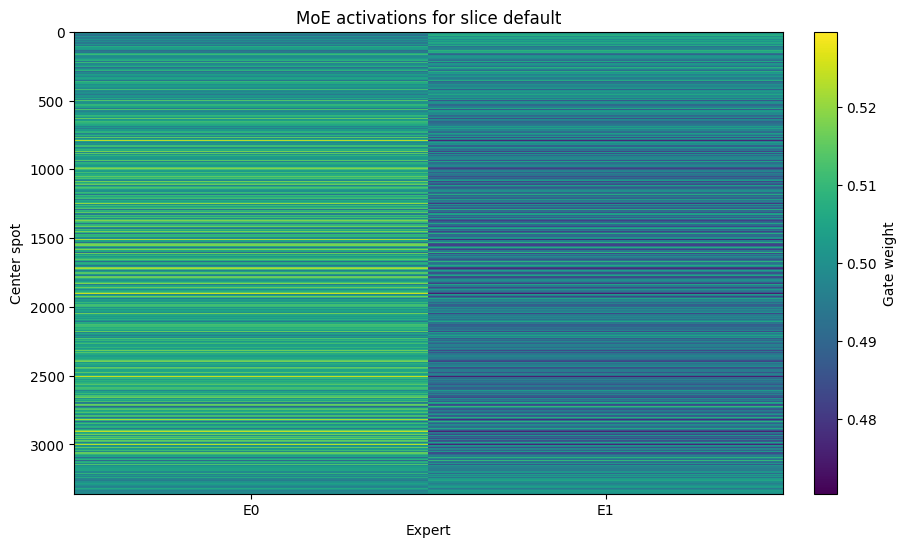

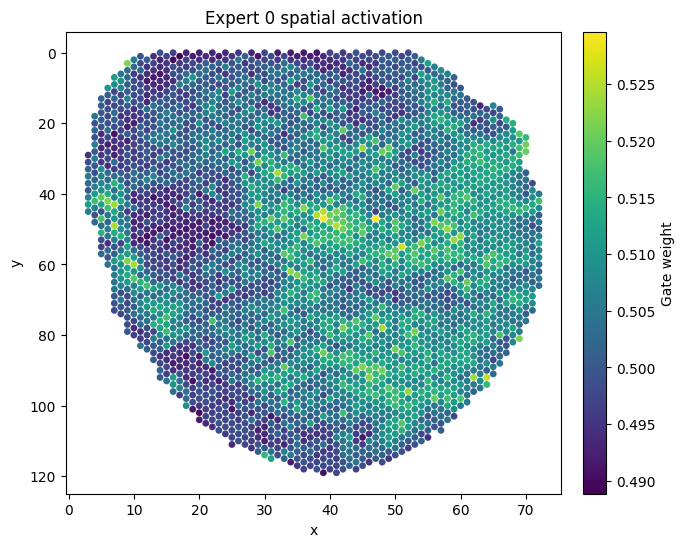

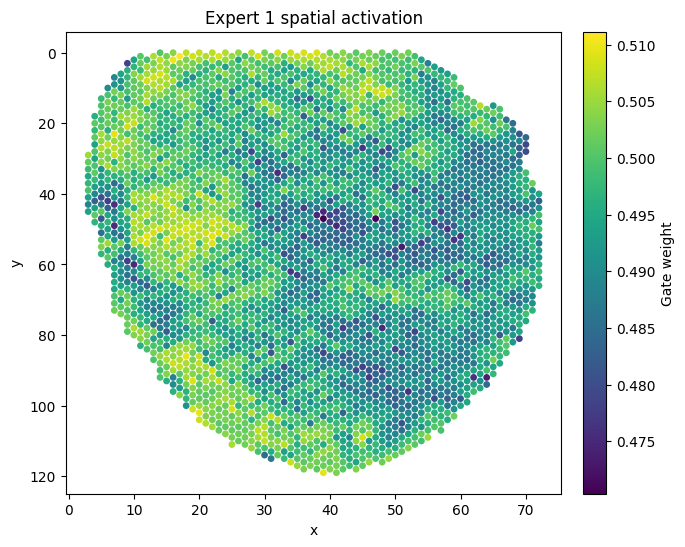

In [42]:
from utils.moe_analysis import (
    analyze_moe_routing,
    plot_center_spot_activation_bar,
    plot_expert_spatial_heatmap,
    plot_slice_activation_heatmap,
    save_moe_analysis_tables,
)

moe_results = analyze_moe_routing(
    model=model,
    dataloader=testloader,
    device=device,
    include_images=False,
    include_cell_information=False,
    include_predictions=False,
    include_targets=True,
)

activation_frame = moe_results["activation_frame"]

print("Overall MoE metrics:")
print(moe_results["overall"])
display(moe_results["expert_summary"])
if not moe_results["slice_summary"].empty:
    display(moe_results["slice_summary"])
if not moe_results["region_summary"].empty:
    display(moe_results["region_summary"])

display(activation_frame.head())
plot_center_spot_activation_bar(activation_frame, row_index=0);

if activation_frame["x"].notna().any() and activation_frame["y"].notna().any():
    first_slice = activation_frame["slice_id"].dropna().iloc[0]
    plot_slice_activation_heatmap(activation_frame, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=0, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=1, slice_id=first_slice);



else:
    print(
        "Spatial coordinates were not recovered from the sample ids. "
        "Pass `sample_metadata_resolver` to `analyze_moe_routing(...)` if you want spatial heatmaps."
    )

# Optional: save the analysis tables to disk.
# save_moe_analysis_tables(moe_results, output_dir="./moe_analysis")



### Optional MoE Training Trajectory Summary

If epoch-level tracking was enabled during training, the next cell summarizes how expert usage changed over time.


,epoch,num_center_spots,num_experts,usage_entropy_normalised,top1_entropy_normalised,effective_expert_count,dominant_expert_fraction,mean_weight_l1_to_uniform,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy
0,1,3359,2,0.999885,0.617351,1.999840,0.506317,0.012634,0.693957,0.692998,0.000185
1,2,3359,2,0.999924,0.725604,1.999895,0.505131,0.010261,0.596308,0.693030,0.000158
2,3,3359,2,0.999908,0.704445,1.999872,0.505658,0.011317,0.617148,0.693010,0.000179
3,4,3359,2,0.999897,0.680975,1.999857,0.505979,0.011959,0.639178,0.693003,0.000184
4,5,3359,2,0.999918,0.757998,1.999886,0.505335,0.010670,0.562370,0.693012,0.000183
5,6,3359,2,0.999931,0.802310,1.999905,0.504880,0.009760,0.511164,0.693021,0.000173
6,7,3359,2,0.999920,0.766113,1.999889,0.505274,0.010548,0.553439,0.693014,0.000179
7,8,3359,2,0.999922,0.789974,1.999893,0.505183,0.010365,0.526049,0.693010,0.000186
8,9,3359,2,0.999921,0.790476,1.999890,0.505247,0.010493,0.525454,0.693007,0.000190
9,10,3359,2,0.999918,0.796443,1.999887,0.505325,0.010650,0.518309,0.693001,0.000199


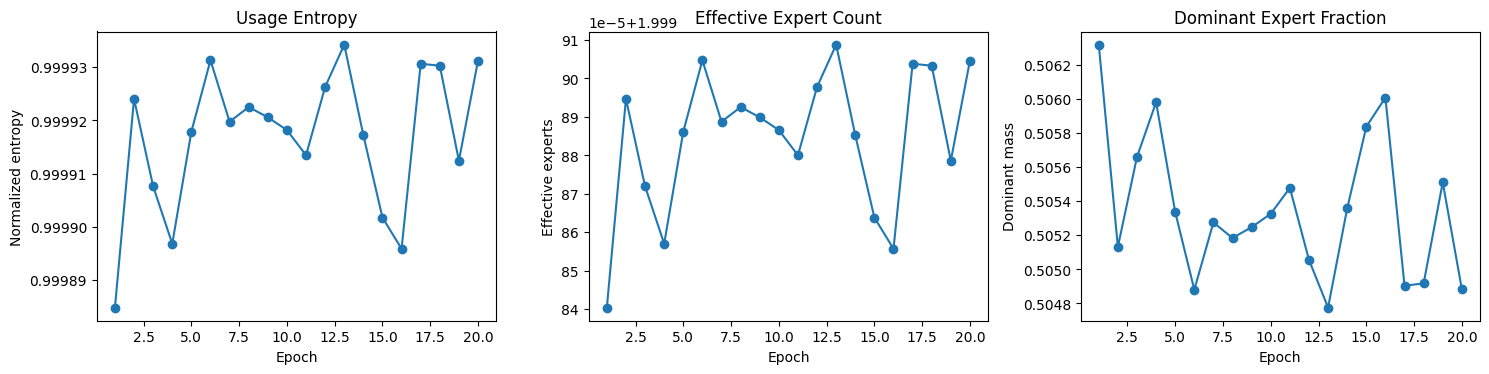

In [43]:
import matplotlib.pyplot as plt

if not moe_epoch_frames:
    print(
        "No epoch-level MoE trajectory was recorded. "
        "Set `track_moe_during_training = True` before training and rerun the notebook if you want this summary."
    )
else:
    moe_epoch_trajectory = summarize_epoch_trajectory(moe_epoch_frames)
    display(moe_epoch_trajectory)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["usage_entropy_normalised"], marker="o")
    axes[0].set_title("Usage Entropy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Normalized entropy")

    axes[1].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["effective_expert_count"], marker="o")
    axes[1].set_title("Effective Expert Count")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Effective experts")

    axes[2].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["dominant_expert_fraction"], marker="o")
    axes[2].set_title("Dominant Expert Fraction")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Dominant mass")

    plt.tight_layout()

# Optional: save the trajectory table to disk.
# moe_epoch_trajectory.to_csv("./moe_analysis/moe_epoch_trajectory.csv", index=False)

